# iiq2img — Usage

In [1]:
from pathlib import Path
from iiq2img import (
    convert_iiq,
    read_iiq,
    batch_convert,
    extract_metadata,
    extract_geo_info,
)

input_dir = Path("PhaseOneSample")
output_dir = Path("output")
sample = next(input_dir.glob("*.IIQ"))

## Single file

In [2]:
out_path = convert_iiq(sample, output_dir / "single.jpg")

print(out_path)

output/single.jpg


## Read as NumPy array

Use `read_iiq` to get the image as an RGB NumPy array without writing any file to disk.

In [3]:
rgb = read_iiq(sample)

print(f"Shape: {rgb.shape}  dtype: {rgb.dtype}")
print(f"Min: {rgb.min()}  Max: {rgb.max()}")

Shape: (9564, 12768, 3)  dtype: uint8
Min: 0  Max: 255


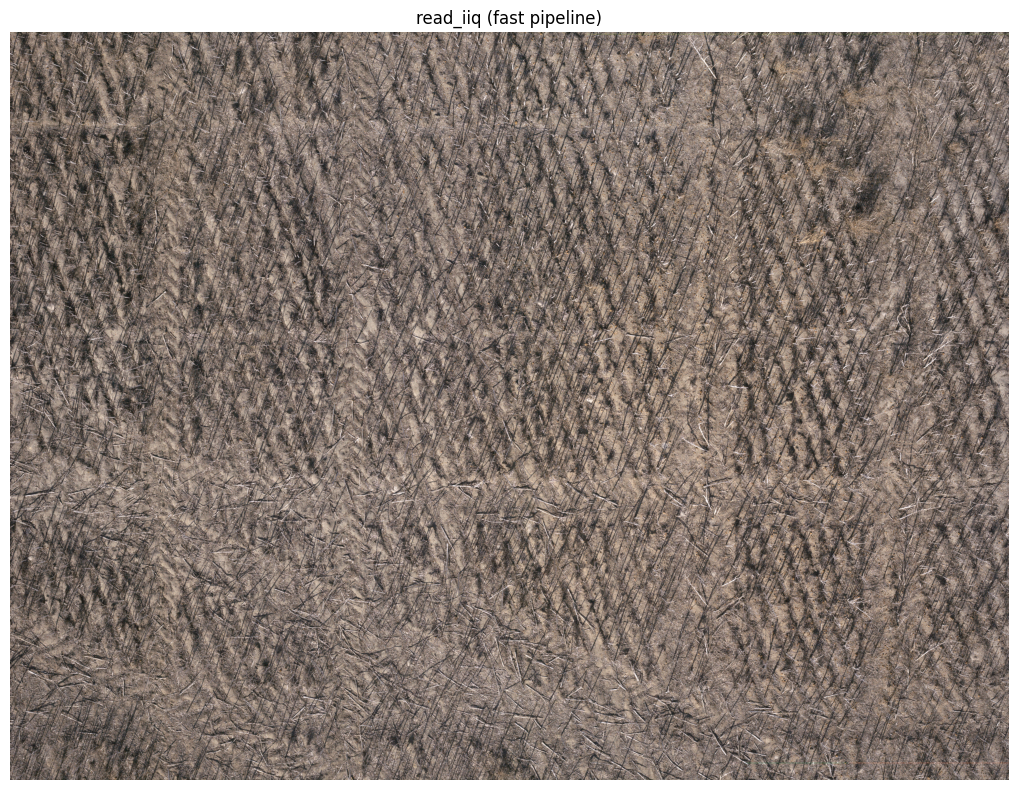

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.imshow(rgb)
plt.axis("off")
plt.title("read_iiq (fast pipeline)")
plt.tight_layout()
plt.show()

In [5]:
# With resize and rotation
rgb_small = read_iiq(sample, max_dimension=2000, rotate=180)

print(f"Shape: {rgb_small.shape}")

Shape: (1498, 2000, 3)


## Batch

In [6]:
results = batch_convert(input_dir, output_dir, workers=8)

  0%|          | 0/4 [00:00<?, ?img/s]

Done: 4 images in 3.9s (avg 984ms/image, 1.0 images/sec, 8 workers)


## Georeferencing

In [7]:
# JPEG + world file (.jgw)
convert_iiq(sample, output_dir / "georef.jpg", georef=True)

# GeoTIFF with embedded CRS
convert_iiq(sample, output_dir / "georef.tif", output_format="tiff", georef=True)

PosixPath('output/georef.tif')

In [8]:
meta = extract_metadata(sample)
geo = extract_geo_info(
    meta["xmp"], focal_length_mm=80.0, image_width=12768, image_height=9564
)
assert geo is not None

print(f"Position:  {geo.latitude:.6f}, {geo.longitude:.6f}")
print(f"Altitude:  {geo.altitude_agl:.1f}m AGL")
print(f"GSD:       {geo.gsd * 100:.2f} cm/pixel")
print(f"Footprint: {geo.footprint_width:.1f}m x {geo.footprint_height:.1f}m")

Position:  -34.561102, 118.376598
Altitude:  26.1m AGL
GSD:       0.11 cm/pixel
Footprint: 14.4m x 10.8m
